In [1]:
!pip install torch torchvision



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\yaswa\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os   
import numpy as np
from tqdm import tqdm

In [9]:
class SingleRNN(nn.Module):
    def __init__(self, n_inputs, n_neurons):
        super(SingleRNN, self).__init__()
        self.Wx = torch.randn(n_inputs, n_neurons) #4X1
        self.Wy = torch.randn(n_neurons, n_neurons) #1X1
        
        self.b = torch.zeros(1, n_neurons) #1X4
    def forward(self, X0, X1):
        self.Y0 = torch.tanh(torch.mm(X0, self.Wx) + self.b)
        self.Y1 = torch.tanh(torch.mm(self.Y0, self.Wy) + self.b)
        return self.Y0, self.Y1

In [10]:
N_INPUT = 4
N_NEURONS = 1

X0_batch = torch.tensor([
    [0,1,2,0],
    [3,4,5,0],
    [6,7,8,0],
    [9,0,1,0]
], dtype=torch.float)

X1_batch = torch.tensor([
    [9,8,7,0],
    [0,0,0,0],
    [6,5,4,0],
    [3,2,1,0]
], dtype=torch.float)

model = SingleRNN(N_INPUT, N_NEURONS)

Y0_val, Y1_val = model(X0_batch, X1_batch)

print(Y0_val)
print(Y1_val)

tensor([[0.9986],
        [1.0000],
        [1.0000],
        [0.9999]])
tensor([[-0.7895],
        [-0.7901],
        [-0.7901],
        [-0.7901]])


In [12]:
import torch

# batch_size = 4
# time_steps = 2
# input_size = 3
X_batch = torch.tensor([
    [[0,1,2],[9,8,7]],
    [[3,4,5],[0,0,0]],
    [[6,7,8],[6,5,4]],
    [[9,0,1],[3,2,1]]
], dtype=torch.float)

class SimpleRNN:
    def __init__(self, n_inputs, n_neurons):
        self.Wx = torch.randn(n_inputs, n_neurons)
        self.Wy = torch.randn(n_neurons, n_neurons)
        self.b = torch.zeros(1, n_neurons)

    def __call__(self, X, h):
        return torch.tanh(torch.mm(X, self.Wx) +
                          torch.mm(h, self.Wy) +
                          self.b)

rnn = SimpleRNN(3, 5)

hx = torch.randn(4, 5)      # batch_size × n_neurons

output = []

# for each time step
for t in range(2):
    hx = rnn(X_batch[:, t], hx)
    output.append(hx)

print(output)

[tensor([[ 0.9901, -0.9997,  0.4770, -0.8865,  0.9997],
        [-0.5516, -1.0000, -1.0000, -0.9147,  0.9997],
        [ 0.8919, -1.0000, -1.0000,  0.9999,  1.0000],
        [-1.0000, -0.9991, -1.0000,  1.0000,  0.9994]]), tensor([[ 0.0029, -1.0000, -1.0000,  1.0000,  1.0000],
        [ 0.1397,  0.9851,  1.0000, -0.9989, -0.3580],
        [ 0.9788, -1.0000, -1.0000,  0.9965,  0.9999],
        [ 0.9353, -0.9933,  0.6639, -0.9689, -0.7594]])]


In [15]:
import torch
import torchvision
import torchvision.transforms as transforms

In [18]:
BATCH_SIZE = 64

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load training dataset
try:
    trainset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
except Exception as e:
    print("MNIST download failed:", e)
    print("Falling back to download=False. If dataset is not present locally, please download it into ./data/MNIST/raw")
    trainset = torchvision.datasets.MNIST(
        root='./data',
        train=True,
        download=False,
        transform=transform
    )

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# Download and load testing dataset
testset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

100%|██████████| 4.54k/4.54k [00:00<00:00, 1.14MB/s]


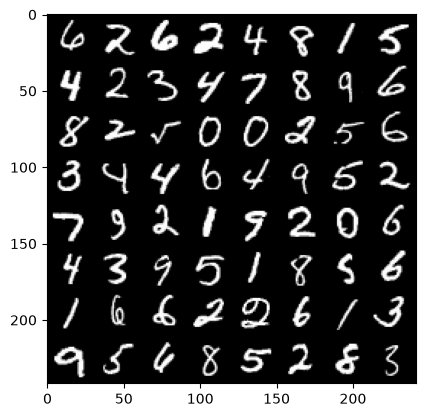

In [19]:
import matplotlib.pyplot as plt
import numpy as np
# functions to show an image
def imshow(img):
    #img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
# get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)
# show images
imshow(torchvision.utils.make_grid(images))

In [20]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)
        return out.view(-1, self.n_outputs) # batch_size X n_output

In [22]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
dataiter = iter(trainloader)
images, labels = next(dataiter)

N_STEPS = 28
N_INPUTS = 28
N_OUTPUTS = 10
N_EPHOCS = 5

model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
logits = model(images.view(-1, 28, 28))
print(logits[0:10])
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[-0.6305, -0.1955, -0.8294,  0.7983,  0.6229, -0.4681,  0.2665,  0.6298,
         -0.9689,  0.8257],
        [-0.4133, -0.3456, -0.8004,  0.9482,  0.7320, -0.7624,  0.2708,  0.9615,
         -1.0739,  0.6176],
        [-0.5079, -0.2802, -0.8130,  0.8829,  0.6845, -0.6341,  0.2689,  0.8170,
         -1.0282,  0.7083],
        [-0.4972, -0.2876, -0.8116,  0.8903,  0.6899, -0.6487,  0.2691,  0.8334,
         -1.0334,  0.6979],
        [-0.4750, -0.3030, -0.8086,  0.9056,  0.7010, -0.6787,  0.2696,  0.8672,
         -1.0441,  0.6767],
        [-0.4906, -0.2922, -0.8107,  0.8948,  0.6932, -0.6576,  0.2693,  0.8434,
         -1.0365,  0.6917],
        [-0.5124, -0.2771, -0.8136,  0.8798,  0.6822, -0.6281,  0.2688,  0.8101,
         -1.0260,  0.7126],
        [-0.6776, -0.1629, -0.8357,  0.7658,  0.5993, -0.4044,  0.2655,  0.5579,
         -0.9461,  0.8708],
        [-0.5320, -0.2635, -0.8162,  0.8662,  0.6724, -0.6015,  0.2684,  0.7802,
         -1.0165,  0.7313],
        [-0.5534, -

In [23]:
import torch.optim as optim
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Model instance
model = ImageRNN(BATCH_SIZE, N_STEPS, N_INPUTS, N_NEURONS, N_OUTPUTS)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [ ]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, BATCH_SIZE)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 2.3718 | Train Accuracy: 11.36
Epoch:  1 | Loss: 2.2582 | Train Accuracy: 15.80
Epoch:  2 | Loss: 2.0297 | Train Accuracy: 23.50
Epoch:  3 | Loss: 1.9240 | Train Accuracy: 24.55
Epoch:  4 | Loss: 1.8781 | Train Accuracy: 28.28


In [ ]:
test_acc= 0.0
for i, data in enumerate(testloader,0):
    inputs, labels = data
    inputs = inputs.view(-1, 28,28)
    outputs = model(inputs)
    test_acc += get_accuracy(outputs, labels, BATCH_SIZE)
print('Test Accuracy: %.2f' %(test_acc/i))